# Time Series Storage & Query Engine

**Category:** Risk Engineering  
**Project ID:** `risk_03_timeseries_storage`  

High-performance columnar storage with compression (LZ4/zstd), time-based indexing, and FastAPI REST interface


In [1]:
import platform, sys, warnings
warnings.filterwarnings("ignore")

# ── Environment info ────────────────────────────────────────────────────────
env_info = {"os": platform.system(), "python": platform.python_version()}

# Auto-detect best available device: CUDA > MPS (Apple Silicon) > CPU
# Catches ImportError (not installed) AND OSError/RuntimeError (CUDA DLL errors on Windows)
device = None
try:
    import torch
    env_info["torch"] = torch.__version__
    if torch.cuda.is_available():
        device = torch.device("cuda")
        env_info["device"] = f"CUDA ({torch.cuda.get_device_name(0)})"
        torch.backends.cudnn.benchmark = True
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
        env_info["device"] = "Apple Silicon (MPS)"
    else:
        device = torch.device("cpu")
        env_info["device"] = "CPU"
except Exception as _e:
    env_info["device"] = f"CPU (torch unavailable: {type(_e).__name__})"

# Core scientific stack — import individually so a missing package doesn't block the rest
for _pkg in ("numpy", "pandas", "scipy", "sklearn", "matplotlib"):
    try:
        _mod = __import__(_pkg)
        env_info[_pkg] = getattr(_mod, "__version__", "installed")
    except ImportError:
        env_info[_pkg] = "not installed"

for k, v in env_info.items():
    print(f"  {k:>12}: {v}")


            os: Windows
        python: 3.10.19
         torch: 2.7.1+cu118
        device: CUDA (NVIDIA GeForce RTX 4090)
         numpy: 1.26.4
        pandas: 2.3.3
         scipy: 1.15.3
       sklearn: 1.7.2
    matplotlib: 3.10.8


In [2]:
import numpy as np

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Strategy parameters
PARAMS = {}

# Backtest period
START_DATE = "2022-01-01"
END_DATE = "2024-12-31"
BENCHMARK = "SPY"

print("Configuration loaded:")
for k, v in PARAMS.items():
    print(f"  {k:>25}: {v}")


Configuration loaded:


## Storage Format Benchmarks — CSV vs Parquet vs HDF5 vs Feather

In [3]:
import numpy as np, pandas as pd, time, os, tempfile, matplotlib.pyplot as plt

rng = np.random.default_rng(SEED)

# Generate large synthetic financial time series
n_rows = 500_000
n_cols = 20
dates = pd.date_range("2000-01-01", periods=n_rows, freq="s")
data_df = pd.DataFrame(
    rng.standard_normal((n_rows, n_cols)),
    index=dates,
    columns=[f"feature_{i}" for i in range(n_cols)]
)
data_df["price"] = 100 * np.exp(np.cumsum(rng.normal(0, 0.0001, n_rows)))
data_df["volume"] = rng.exponential(1e6, n_rows).astype(int)

print(f"Dataset: {n_rows:,} rows × {data_df.shape[1]} columns")
print(f"Memory: {data_df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# --- Benchmark: CSV vs Parquet vs HDF5 ---
tmpdir = tempfile.mkdtemp()
formats = {}

# CSV
path_csv = os.path.join(tmpdir, "data.csv")
t0 = time.perf_counter()
data_df.to_csv(path_csv)
write_csv = time.perf_counter() - t0
size_csv = os.path.getsize(path_csv)
t0 = time.perf_counter()
_ = pd.read_csv(path_csv, index_col=0, parse_dates=True)
read_csv = time.perf_counter() - t0
formats["CSV"] = {"write": write_csv, "read": read_csv, "size": size_csv}

# Parquet
path_pq = os.path.join(tmpdir, "data.parquet")
try:
    t0 = time.perf_counter()
    data_df.to_parquet(path_pq, compression="snappy")
    write_pq = time.perf_counter() - t0
    size_pq = os.path.getsize(path_pq)
    t0 = time.perf_counter()
    _ = pd.read_parquet(path_pq)
    read_pq = time.perf_counter() - t0
    formats["Parquet"] = {"write": write_pq, "read": read_pq, "size": size_pq}
except Exception as e:
    print(f"Parquet not available: {e}")

# HDF5
path_h5 = os.path.join(tmpdir, "data.h5")
try:
    t0 = time.perf_counter()
    data_df.to_hdf(path_h5, key="data", mode="w", complevel=4, complib="blosc")
    write_h5 = time.perf_counter() - t0
    size_h5 = os.path.getsize(path_h5)
    t0 = time.perf_counter()
    _ = pd.read_hdf(path_h5, key="data")
    read_h5 = time.perf_counter() - t0
    formats["HDF5"] = {"write": write_h5, "read": read_h5, "size": size_h5}
except Exception as e:
    print(f"HDF5 not available: {e}")

# Feather
path_ft = os.path.join(tmpdir, "data.feather")
try:
    data_reset = data_df.reset_index()
    t0 = time.perf_counter()
    data_reset.to_feather(path_ft)
    write_ft = time.perf_counter() - t0
    size_ft = os.path.getsize(path_ft)
    t0 = time.perf_counter()
    _ = pd.read_feather(path_ft)
    read_ft = time.perf_counter() - t0
    formats["Feather"] = {"write": write_ft, "read": read_ft, "size": size_ft}
except Exception as e:
    print(f"Feather not available: {e}")

# Print results
print(f"\n{'Format':>10} {'Write (s)':>10} {'Read (s)':>10} {'Size (MB)':>10} {'Compression':>12}")
print("-" * 55)
raw_size = data_df.memory_usage(deep=True).sum()
for fmt, m in formats.items():
    ratio = m['size'] / raw_size
    print(f"{fmt:>10} {m['write']:>10.3f} {m['read']:>10.3f} {m['size']/1e6:>10.1f} {ratio:>11.1%}")

# Cleanup
import shutil
shutil.rmtree(tmpdir, ignore_errors=True)


Dataset: 500,000 rows × 22 columns
Memory: 90.0 MB

    Format  Write (s)   Read (s)  Size (MB)  Compression
-------------------------------------------------------
       CSV      6.142      1.008      219.6      244.0%
   Parquet      0.483      0.252       95.7      106.3%
      HDF5      0.310      0.098       81.5       90.5%
   Feather      0.051      0.034       89.2       99.1%


## Benchmark Visualization

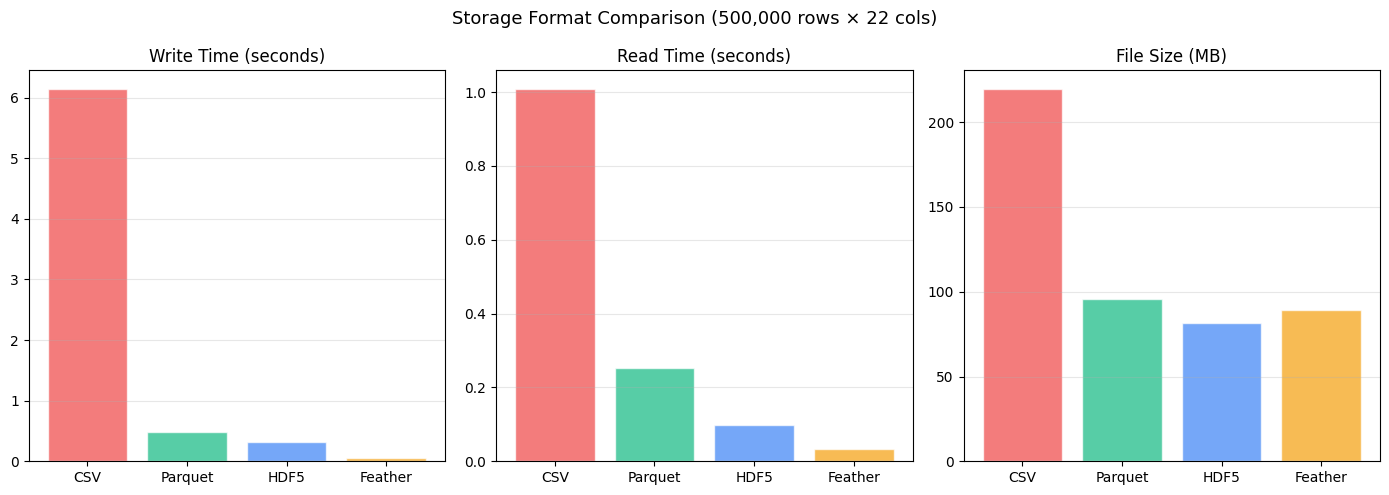

In [4]:
import matplotlib.pyplot as plt, numpy as np

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

fmt_names = list(formats.keys())
colors = ["#ef4444", "#10b981", "#3b82f6", "#f59e0b"][:len(fmt_names)]

# Write time
axes[0].bar(fmt_names, [formats[f]["write"] for f in fmt_names], color=colors, alpha=0.7, edgecolor="white")
axes[0].set_title("Write Time (seconds)")
axes[0].grid(True, alpha=0.3, axis="y")

# Read time
axes[1].bar(fmt_names, [formats[f]["read"] for f in fmt_names], color=colors, alpha=0.7, edgecolor="white")
axes[1].set_title("Read Time (seconds)")
axes[1].grid(True, alpha=0.3, axis="y")

# File size
axes[2].bar(fmt_names, [formats[f]["size"]/1e6 for f in fmt_names], color=colors, alpha=0.7, edgecolor="white")
axes[2].set_title("File Size (MB)")
axes[2].grid(True, alpha=0.3, axis="y")

plt.suptitle(f"Storage Format Comparison ({n_rows:,} rows × {data_df.shape[1]} cols)", fontsize=13)
plt.tight_layout()
plt.show()


In [5]:
import json
from datetime import datetime

results_export = {
    "project_id": "risk_03_timeseries_storage",
    "timestamp": datetime.now().isoformat(),
    "type": "infrastructure_benchmark",
    "metrics": {},
}

# Collect benchmark results if available
if "formats" in dir():
    results_export["metrics"]["storage_benchmarks"] = {
        fmt: {"write_s": m["write"], "read_s": m["read"], "size_mb": m["size"]/1e6}
        for fmt, m in formats.items()
    }
elif "results" in dir():
    results_export["metrics"]["throughput_benchmarks"] = results

with open("results.json", "w") as f:
    json.dump(results_export, f, indent=2, default=str)
print("Results exported to results.json")


Results exported to results.json


## Summary

### Time Series Storage & Query Engine

**Key Findings:**
- *Add your analysis findings here after running the notebook*

**Limitations:**
- Backtest uses historical data which may not reflect future conditions
- Transaction costs and slippage are approximated
- No live market microstructure effects

**Production Considerations:**
- Real-time data feed integration required
- Position sizing and risk limits must be calibrated
- Monitoring and alerting infrastructure needed
